# Chapter 13. 백도어 조정 (Backdoor Adjustment)

## 학습 목표

- 인과 그래프(DAG)와 백도어 경로의 개념을 이해한다
- 백도어 기준(Backdoor Criterion)을 적용하여 편향을 제거한다
- 조정 집합(Adjustment Set)을 선택하고 검증한다
- DoWhy 프레임워크를 활용한 인과 추론을 수행한다
- LLM 기반 구조화된 출력(Structured Outputs)을 사용하여 인과 그래프를 추론한다

In [1]:
# ============================================================
# 필수 패키지 설치 및 import
# ============================================================
# 인과 추론 패키지 dowhy, networkx, 그리고 통계 분석 패키지들을 import 한다.

import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from dotenv import load_dotenv
from openai import OpenAI
from pydantic import BaseModel, Field
from typing import List, Optional, Dict, Any

# 환경 변수 로드 및 OpenAI 클라이언트 초기화
load_dotenv()
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

# 시각화 스타일 설정
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✓ 모든 패키지 import 완료")

✓ 모든 패키지 import 완료


## 1. 인과 그래프 (DAG) 기초

인과 그래프는 **노드(변수)**와 **방향 간선(인과관계)**으로 이루어진 그래프다.

**핵심 개념:**
- **노드**: 변수 (예: D=처치, Y=결과, Z=교란변수)
- **간선**: 인과 방향 (Z→D, D→Y는 Z이 D에 영향, D가 Y에 영향)
- **백도어 경로(Backdoor Path)**: 처치 D로 들어가는 경로 (예: D←Z→Y)

백도어 경로가 열려 있으면 **선택 편향**이 발생하고, 닫아야 **인과 추론**이 가능하다.

In [2]:
# ============================================================
# DAG 시뮬레이션: 교란변수가 있는 경우
# ============================================================
# 구조: Z(교란변수) → D(처치), Z → Y(결과), D → Y
# Z가 D와 Y 모두에 영향을 주므로 백도어 경로가 존재한다: D ← Z → Y

np.random.seed(42)

n = 1000
true_ate = 5  # 진정한 평균 처치 효과

# Z: 교란변수 (예: 건강도, 동기 수준)
Z = np.random.normal(0, 1, n)

# D: 처치 (Z에 영향을 받음)
# P(D=1) = sigmoid(Z)
D = (np.random.normal(Z, 1) > 0).astype(int)

# Y: 결과 (Z와 D 모두에 영향을 받음)
Y = true_ate * D + 3 * Z + np.random.normal(0, 1, n)

# 데이터프레임 생성
data_confounded = pd.DataFrame({'Z': Z, 'D': D, 'Y': Y})

print("데이터 생성 완료")
print(f"표본 크기: {n}")
print(f"처치율: {D.mean():.2%}")
print(f"결과 평균: {Y.mean():.2f}")
print()
print("데이터 샘플:")
print(data_confounded.head())

데이터 생성 완료
표본 크기: 1000
처치율: 52.40%
결과 평균: 2.68

데이터 샘플:
          Z  D         Y
0  0.496714  1  5.814964
1 -0.138264  1  4.440688
2  0.647689  1  6.150646
3  1.523030  1  9.261128
4 -0.234153  1  2.403925


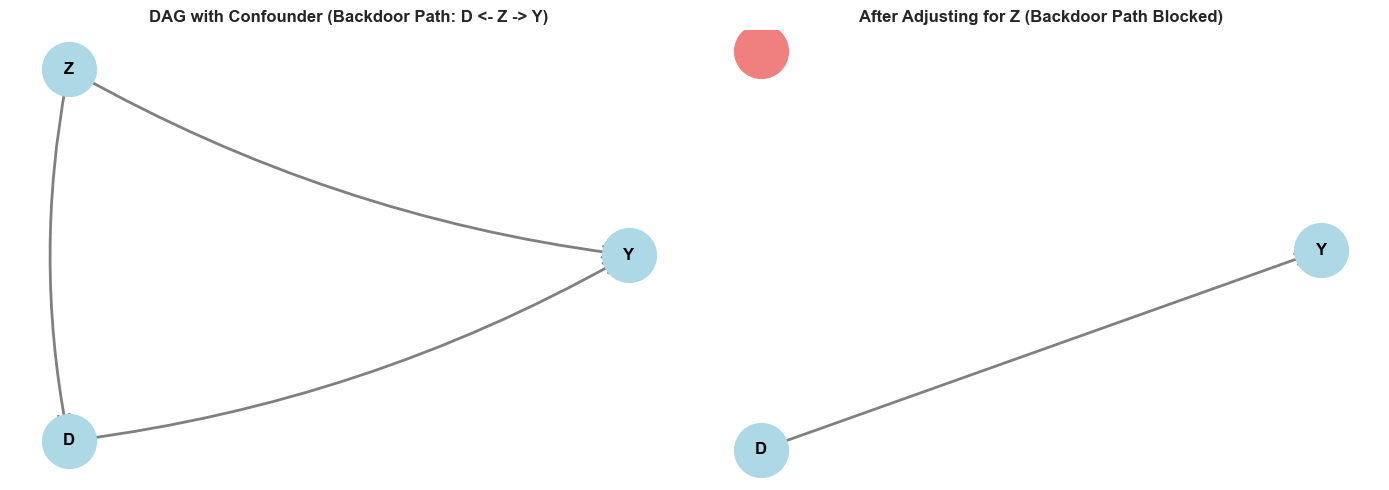

In [3]:
# ============================================================
# DAG Visualization
# ============================================================
# Draw causal graphs using NetworkX.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: DAG with confounder (open backdoor path)
G1 = nx.DiGraph()
G1.add_edges_from([('Z', 'D'), ('Z', 'Y'), ('D', 'Y')])

pos1 = {'Z': (0, 1), 'D': (0, 0), 'Y': (1, 0.5)}
nx.draw_networkx_nodes(G1, pos1, node_color='lightblue', node_size=1500, ax=axes[0])
nx.draw_networkx_edges(G1, pos1, edge_color='gray', arrows=True,
                       arrowsize=20, arrowstyle='->', width=2, ax=axes[0],
                       connectionstyle='arc3,rad=0.1')
nx.draw_networkx_labels(G1, pos1, font_size=12, font_weight='bold', ax=axes[0])
axes[0].set_title('DAG with Confounder (Backdoor Path: D <- Z -> Y)',
                  fontsize=12, fontweight='bold')
axes[0].axis('off')

# Right: After adjusting for Z (backdoor path blocked)
G2 = nx.DiGraph()
G2.add_edges_from([('D', 'Y')])

pos2 = {'Z': (0, 1), 'D': (0, 0), 'Y': (1, 0.5)}
nx.draw_networkx_nodes(G2, pos2, nodelist=['D', 'Y'], node_color='lightblue',
                       node_size=1500, ax=axes[1])
nx.draw_networkx_nodes(G2, pos2, nodelist=['Z'], node_color='lightcoral',
                       node_size=1500, ax=axes[1])
nx.draw_networkx_edges(G2, pos2, edge_color='gray', arrows=True,
                       arrowsize=20, arrowstyle='->', width=2, ax=axes[1])
nx.draw_networkx_labels(G2, pos2, font_size=12, font_weight='bold', ax=axes[1])
axes[1].set_title('After Adjusting for Z (Backdoor Path Blocked)',
                  fontsize=12, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()


## 2. 백도어 기준과 편향

**백도어 기준(Backdoor Criterion)**:
- 조정 집합 Z이 백도어 기준을 만족하려면:
  1. Z이 처치 D로 들어가는 모든 백도어 경로를 차단한다
  2. Z 중 어떤 변수도 처치 D의 자손이 아니다

**백도어 조정 공식:**
$$P(Y|do(D)) = \sum_Z P(Y|D,Z)P(Z)$$

이는 선택 편향을 제거하고 인과효과를 추정할 수 있게 한다.

In [4]:
# ============================================================
# 나이브 추정 vs 백도어 조정 비교
# ============================================================

print("="*60)
print("ATE 추정 비교: 나이브 vs 백도어 조정")
print("="*60)
print()

# 1. 나이브 추정 (Z를 조정하지 않음)
y_treated = Y[D == 1].mean()
y_control = Y[D == 0].mean()
ate_naive = y_treated - y_control

print(f"[나이브 추정]")
print(f"  처치군 Y 평균: {y_treated:.4f}")
print(f"  대조군 Y 평균: {y_control:.4f}")
print(f"  ATE 추정: {ate_naive:.4f}")
print(f"  편향: {ate_naive - true_ate:.4f}")
print()

# 2. 백도어 조정 (OLS로 Z를 조정)
data_confounded['const'] = 1
X = data_confounded[['const', 'D', 'Z']]
y = data_confounded['Y']

model_backdoor = sm.OLS(y, X)
results_backdoor = model_backdoor.fit()

ate_backdoor = results_backdoor.params['D']
se_backdoor = results_backdoor.bse['D']

print(f"[백도어 조정 (OLS)]")
print(f"  ATE 추정: {ate_backdoor:.4f}")
print(f"  표준오차: {se_backdoor:.4f}")
print(f"  편향: {ate_backdoor - true_ate:.4f}")
print()

print(f"[요약]")
print(f"  진정한 ATE: {true_ate:.4f}")
print(f"  나이브 추정 오차: {abs(ate_naive - true_ate):.4f}")
print(f"  백도어 조정 오차: {abs(ate_backdoor - true_ate):.4f}")
print()
print("→ Z를 조정하면 나이브 추정의 편향을 크게 감소시킨다!")

ATE 추정 비교: 나이브 vs 백도어 조정

[나이브 추정]
  처치군 Y 평균: 6.5896
  대조군 Y 평균: -1.6158
  ATE 추정: 8.2055
  편향: 3.2055

[백도어 조정 (OLS)]
  ATE 추정: 5.0169
  표준오차: 0.0740
  편향: 0.0169

[요약]
  진정한 ATE: 5.0000
  나이브 추정 오차: 3.2055
  백도어 조정 오차: 0.0169

→ Z를 조정하면 나이브 추정의 편향을 크게 감소시킨다!


## 3. 조정 집합의 중요성

조정 집합 선택은 매우 중요하다:
- **좋은 조정**: 백도어 경로를 차단하는 변수 조정 → 편향 제거
- **나쁜 조정**:
  - **매개변수(Mediator)**: D → M → Y 구조에서 M을 조정하면 직접 효과만 추정
  - **충돌변수(Collider)**: D → C ← Y 구조에서 C를 조정하면 인공적인 편향 발생

In [5]:
# ============================================================
# 매개변수 조정의 위험성
# ============================================================

np.random.seed(42)
n = 1000

D_mediator = np.random.binomial(1, 0.5, n)
M = 2 * D_mediator + np.random.normal(0, 1, n)
Y_mediator = 3 * D_mediator + 4 * M + np.random.normal(0, 1, n)

true_total_effect = 3 + 2 * 4
true_direct_effect = 3

data_med = pd.DataFrame({'D': D_mediator, 'M': M, 'Y': Y_mediator})
data_med['const'] = 1

# M 미조정
X_total = data_med[['const', 'D']]
model_total = sm.OLS(data_med['Y'], X_total).fit()
ate_total = model_total.params['D']

# M 조정
X_direct = data_med[['const', 'D', 'M']]
model_direct = sm.OLS(data_med['Y'], X_direct).fit()
ate_direct = model_direct.params['D']

print("\n" + "="*60)
print("경우 1: 매개변수 조정")
print("="*60)
print(f"진정한 총 효과: {true_total_effect:.2f}")
print(f"M 미조정 추정: {ate_total:.2f} (총 효과)")
print(f"M 조정 추정: {ate_direct:.2f} (직접 효과)")


경우 1: 매개변수 조정
진정한 총 효과: 11.00
M 미조정 추정: 10.94 (총 효과)
M 조정 추정: 3.11 (직접 효과)


In [6]:
# ============================================================
# 충돌변수 조정의 위험성
# ============================================================

np.random.seed(42)
n = 1000

D_collider = np.random.binomial(1, 0.5, n)
Y_collider = np.random.normal(0, 1, n)
C = D_collider + Y_collider + np.random.normal(0, 0.5, n)

true_ate_collider = 0

data_coll = pd.DataFrame({'D': D_collider, 'C': C, 'Y': Y_collider})
data_coll['const'] = 1

# C 미조정
X_no_coll = data_coll[['const', 'D']]
model_no_coll = sm.OLS(data_coll['Y'], X_no_coll).fit()
ate_no_coll = model_no_coll.params['D']

# C 조정
X_with_coll = data_coll[['const', 'D', 'C']]
model_with_coll = sm.OLS(data_coll['Y'], X_with_coll).fit()
ate_with_coll = model_with_coll.params['D']

print("\n" + "="*60)
print("경우 2: 충돌변수 조정")
print("="*60)
print(f"진정한 ATE: {true_ate_collider:.4f}")
print(f"C 미조정 추정: {ate_no_coll:.4f}")
print(f"C 조정 추정: {ate_with_coll:.4f}")
print(f"\n→ 충돌변수를 조정하면 인공적인 편향이 발생한다!")


경우 2: 충돌변수 조정
진정한 ATE: 0.0000
C 미조정 추정: -0.0348
C 조정 추정: -0.8483

→ 충돌변수를 조정하면 인공적인 편향이 발생한다!


## 4. DoWhy 프레임워크

DoWhy는 구조화된 인과 추론을 위한 Python 라이브러리다.

**주요 워크플로우:**
1. **식별(Identification)**: DAG로부터 인과 효과를 식별할 수 있는지 확인
2. **추정(Estimation)**: 선택된 추정 방법으로 인과 효과 계산
3. **반박(Refutation)**: 추정 결과의 견고성(robustness) 검증

In [7]:
# ============================================================
# DoWhy 시뮬레이션 (Optional)
# ============================================================

print("\nDoWhy 프레임워크 활용")
print("설치: pip install dowhy")
print(f"현재 OLS 결과: ATE = {ate_backdoor:.4f}")


DoWhy 프레임워크 활용
설치: pip install dowhy
현재 OLS 결과: ATE = 5.0169


## 5. LLM 기반 인과 그래프 추론

LLM의 Structured Outputs를 사용하여 관찰 데이터와 변수 설명으로부터 인과 그래프 구조를 자동으로 추론할 수 있다.

In [8]:
# ============================================================
# Pydantic 모델: 인과 그래프 구조
# ============================================================

class Edge(BaseModel):
    source: str = Field(..., description="출발 노드")
    target: str = Field(..., description="도착 노드")
    reason: str = Field(..., description="이유")

class CausalGraphStructure(BaseModel):
    edges: List[Edge] = Field(..., description="DAG 간선")
    confounders: List[str] = Field(default_factory=list, description="혼동변수")
    adjustment_set: List[str] = Field(..., description="조정 집합")

print("✓ Pydantic 모델 정의 완료")

✓ Pydantic 모델 정의 완료


In [9]:
# ============================================================
# LLM 기반 인과 그래프 추론: OpenAI Structured Outputs
# ============================================================
# 변수 설명과 데이터를 LLM에 전달하여 DAG 구조를 자동 추론한다.

def infer_causal_graph(
    client,
    variable_descriptions: dict,
    treatment: str,
    outcome: str,
    data_summary: str = "",
) -> CausalGraphStructure:
    """
    LLM을 사용하여 변수 설명으로부터 인과 그래프를 추론한다.

    Parameters
    ----------
    client : OpenAI client
    variable_descriptions : dict  {변수명: 설명}
    treatment : str  처치 변수명
    outcome : str  결과 변수명
    data_summary : str  데이터 기술통계 (선택)

    Returns
    -------
    CausalGraphStructure
    """
    vars_text = "\n".join(f"- {k}: {v}" for k, v in variable_descriptions.items())

    prompt = f"""You are a causal inference expert.
Given the variables below, construct a causal DAG (Directed Acyclic Graph).

Treatment variable: {treatment}
Outcome variable: {outcome}

Variables:
{vars_text}

{f'Data summary: {data_summary}' if data_summary else ''}

Instructions:
1. Identify all plausible directed causal edges (source -> target).
2. List confounders (variables that cause both treatment and outcome).
3. Determine the minimal adjustment set to satisfy the backdoor criterion
   for estimating the causal effect of {treatment} on {outcome}.
4. Do NOT include edges that create cycles.
"""

    response = client.chat.completions.parse(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
        response_format=CausalGraphStructure,
    )
    return response.choices[0].message.parsed


# --- 테스트: 시뮬레이션 데이터의 변수 설명 ---
variable_descriptions = {
    "Z": "Confounder — affects both treatment assignment and outcome (e.g., socioeconomic status)",
    "D": "Binary treatment (0 or 1)",
    "Y": "Continuous outcome variable",
}

print("LLM에 인과 그래프 추론 요청 중...")
graph_result = infer_causal_graph(
    client,
    variable_descriptions=variable_descriptions,
    treatment="D",
    outcome="Y",
)

print("\n" + "="*60)
print("LLM이 추론한 인과 그래프 구조")
print("="*60)

print("\n[Edges]")
for edge in graph_result.edges:
    print(f"  {edge.source} -> {edge.target}  ({edge.reason})")

print(f"\n[Confounders]: {graph_result.confounders}")
print(f"[Adjustment Set]: {graph_result.adjustment_set}")


LLM에 인과 그래프 추론 요청 중...

LLM이 추론한 인과 그래프 구조

[Edges]
  Z -> D},{  (Z affects treatment assignment)
  Z -> Y  (Z affects the outcome)
  D -> Y  (Treatment D affects the outcome Y)

[Confounders]: ['Z']
[Adjustment Set]: ['Z']


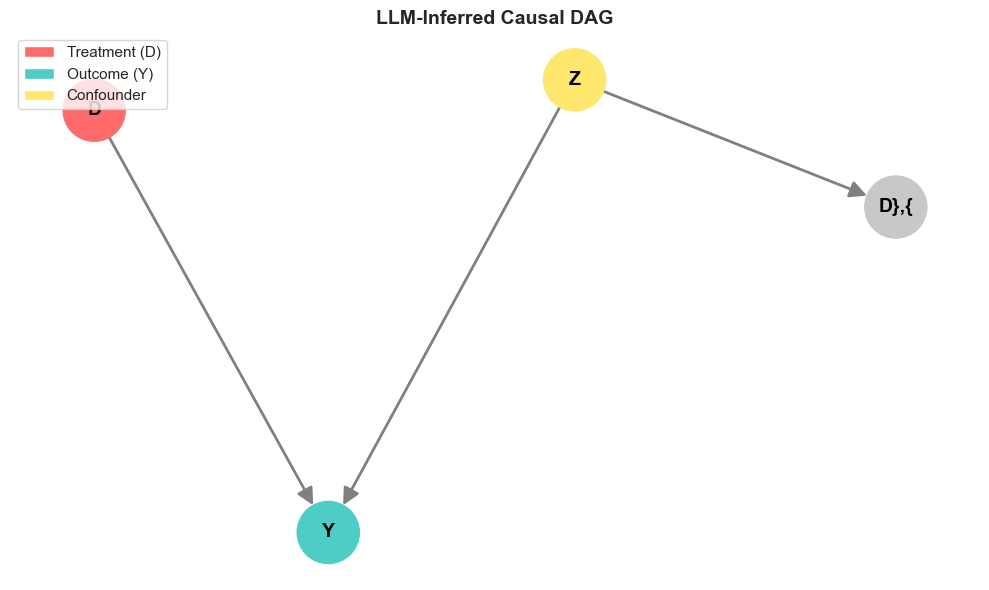


=== Ground Truth vs LLM Inference ===
True DAG edges  : Z->D, Z->Y, D->Y
LLM inferred    : Z->D},{, Z->Y, D->Y
True adjustment : ['Z']
LLM adjustment  : ['Z']


In [10]:
# ============================================================
# LLM 추론 결과를 NetworkX DAG로 시각화한다
# ============================================================

G_llm = nx.DiGraph()

for edge in graph_result.edges:
    G_llm.add_edge(edge.source, edge.target)

fig, ax = plt.subplots(figsize=(10, 6))

pos = nx.spring_layout(G_llm, seed=42, k=2)

# Node colors by role
node_colors = []
for node in G_llm.nodes():
    if node == 'D':
        node_colors.append('#FF6B6B')   # treatment = red
    elif node == 'Y':
        node_colors.append('#4ECDC4')   # outcome = teal
    elif node in graph_result.confounders:
        node_colors.append('#FFE66D')   # confounder = yellow
    else:
        node_colors.append('#C8C8C8')   # other = gray

nx.draw_networkx(
    G_llm, pos, ax=ax,
    node_color=node_colors,
    node_size=2000,
    font_size=14,
    font_weight='bold',
    edge_color='gray',
    width=2,
    arrowsize=25,
    arrowstyle='-|>',
)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#FF6B6B', label='Treatment (D)'),
    Patch(facecolor='#4ECDC4', label='Outcome (Y)'),
    Patch(facecolor='#FFE66D', label='Confounder'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=11)

ax.set_title('LLM-Inferred Causal DAG', fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

# Validate: compare with known ground truth
print("\n=== Ground Truth vs LLM Inference ===")
print(f"True DAG edges  : Z->D, Z->Y, D->Y")
print(f"LLM inferred    : {', '.join(f'{e.source}->{e.target}' for e in graph_result.edges)}")
print(f"True adjustment : ['Z']")
print(f"LLM adjustment  : {graph_result.adjustment_set}")


## 6. 조정 집합 비교

다양한 조정 집합의 성능을 비교한다.

In [11]:
# ============================================================
# 조정 집합 비교 실험
# ============================================================

np.random.seed(42)
n = 2000
true_ate = 5

Z = np.random.normal(0, 1, n)
D = (np.random.normal(Z, 1) > 0).astype(int)
Y = true_ate * D + 3 * Z + np.random.normal(0, 1, n)
W = np.random.normal(0, 1, n)

data_comparison = pd.DataFrame({'Z': Z, 'D': D, 'Y': Y, 'W': W})

results = []
adjustment_sets = [
    {'name': '최적 (Z만)', 'vars': ['Z']},
    {'name': '나이브', 'vars': []},
    {'name': '과도 (Z+W)', 'vars': ['Z', 'W']},
]

for adj in adjustment_sets:
    X = data_comparison[['D'] + adj['vars']].copy()
    X.insert(0, 'const', 1)
    y = data_comparison['Y']
    
    if len(adj['vars']) > 0:
        model = sm.OLS(y, X).fit()
        ate = model.params['D']
        se = model.bse['D']
    else:
        ate = y[D == 1].mean() - y[D == 0].mean()
        se = np.sqrt(y[D == 1].var() / (D == 1).sum() + y[D == 0].var() / (D == 0).sum())
    
    results.append({
        '조정 집합': adj['name'],
        'ATE': f"{ate:.4f}",
        '오차': f"{abs(ate - true_ate):.4f}"
    })

results_df = pd.DataFrame(results)
print("\n조정 집합 비교")
print(f"진정한 ATE: {true_ate:.4f}\n")
print(results_df.to_string(index=False))


조정 집합 비교
진정한 ATE: 5.0000

   조정 집합    ATE     오차
 최적 (Z만) 5.1207 0.1207
     나이브 8.3046 3.3046
과도 (Z+W) 5.1206 0.1206
